In [1]:
!pip install torch torchvision

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from scipy.stats import entropy

# Thêm thư mục gốc vào path để import src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils import load_cifar10_longtail
from src.model import hierarchical_kmeans_resampling
from src.metrics import calculate_acc, calculate_nmi # Đảm bảo bạn đã có hàm này trong metrics.py

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hệ thống sẵn sàng. Thiết bị sử dụng: {device}")

d:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Hệ thống sẵn sàng. Thiết bị sử dụng: cpu


Đã load xong đặc trưng: (20431, 384)
Đã load xong nhãn Long-tail: (20431,)


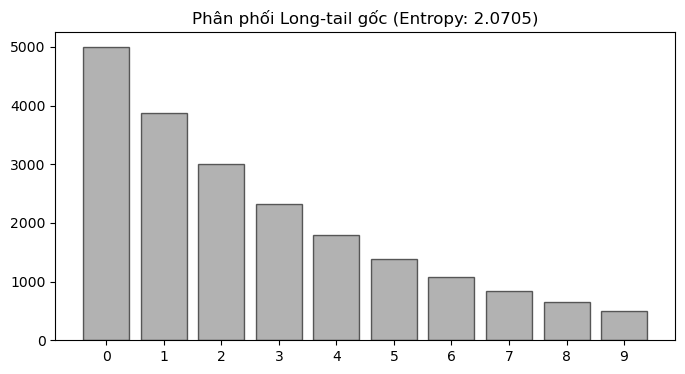

In [2]:
# 1. Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.model import hierarchical_kmeans_resampling
from src.metrics import calculate_acc, calculate_nmi

# 2. Load dữ liệu từ folder processed (Dùng đúng tên file trong ảnh của bạn)
X_feats_raw = np.load('../data/processed/X_features_cifar_0.1.npy')
Y_longtail = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

# 3. Chuẩn hóa L2 (Cực kỳ quan trọng để K-means chạy chuẩn trên đặc trưng DINOv2)
X_feats_norm = normalize(X_feats_raw)

print(f"Đã load xong đặc trưng: {X_feats_norm.shape}")
print(f"Đã load xong nhãn Long-tail: {Y_longtail.shape}")

# Trực quan hóa phân phối Long-tail ban đầu
classes, counts = np.unique(Y_longtail, return_counts=True)
ent_raw = entropy(counts/len(Y_longtail))
plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color='gray', alpha=0.6, edgecolor='black')
plt.title(f"Phân phối Long-tail gốc (Entropy: {ent_raw:.4f})")
plt.xticks(range(10))
plt.show()

In [ ]:
# Cấu hình k_list theo tỷ lệ giảm dần của bài báo
# Tầng 1: 1000 cụm (xẻ nhỏ vùng đậm đặc), Tầng cuối: 100 cụm (Concepts)
k_list = [4000, 2000, 1000] 
r_t_list = [5, 2, 1] 

print("Đang chạy Hierarchical K-means Resampling...")
centroids_final = hierarchical_kmeans_resampling(
    X_feats_norm, k_list, T=3, m=10, r_t_list=r_t_list, num_init=3
)

# Gán nhãn cụm cho toàn bộ ảnh
km_final = KMeans(n_clusters=1000, init=centroids_final, n_init=1).fit(X_feats_norm)
cluster_labels = km_final.labels_

Đang chạy Hierarchical K-means Resampling...
--- Level 1/3 (k=4000, r_t=5) ---
--- Level 2/3 (k=2000, r_t=2) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than av

--- Level 3/3 (k=1000, r_t=1) ---


d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
d:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

In [4]:
from sklearn.decomposition import PCA
from src.metrics import calculate_kl_divergence # Hàm bạn đã dùng cho simulated data
import numpy as np

# 1. Khởi tạo PCA để đưa đặc trưng 384D về 2D (để tính được KL)
pca = PCA(n_components=2, random_state=42)
X_pca_raw = pca.fit_transform(X_feats_norm)

def get_kl_for_subset(X_subset_norm):
    """Giảm chiều tập con và tính KL Divergence"""
    X_pca_subset = pca.transform(X_subset_norm)
    # L=4 vì dữ liệu chuẩn hóa thường nằm trong khoảng này sau PCA
    return calculate_kl_divergence(X_pca_subset, L=4, step=0.1, bandwidth=0.5)

Đang tính toán các chỉ số cho 2114 mẫu...


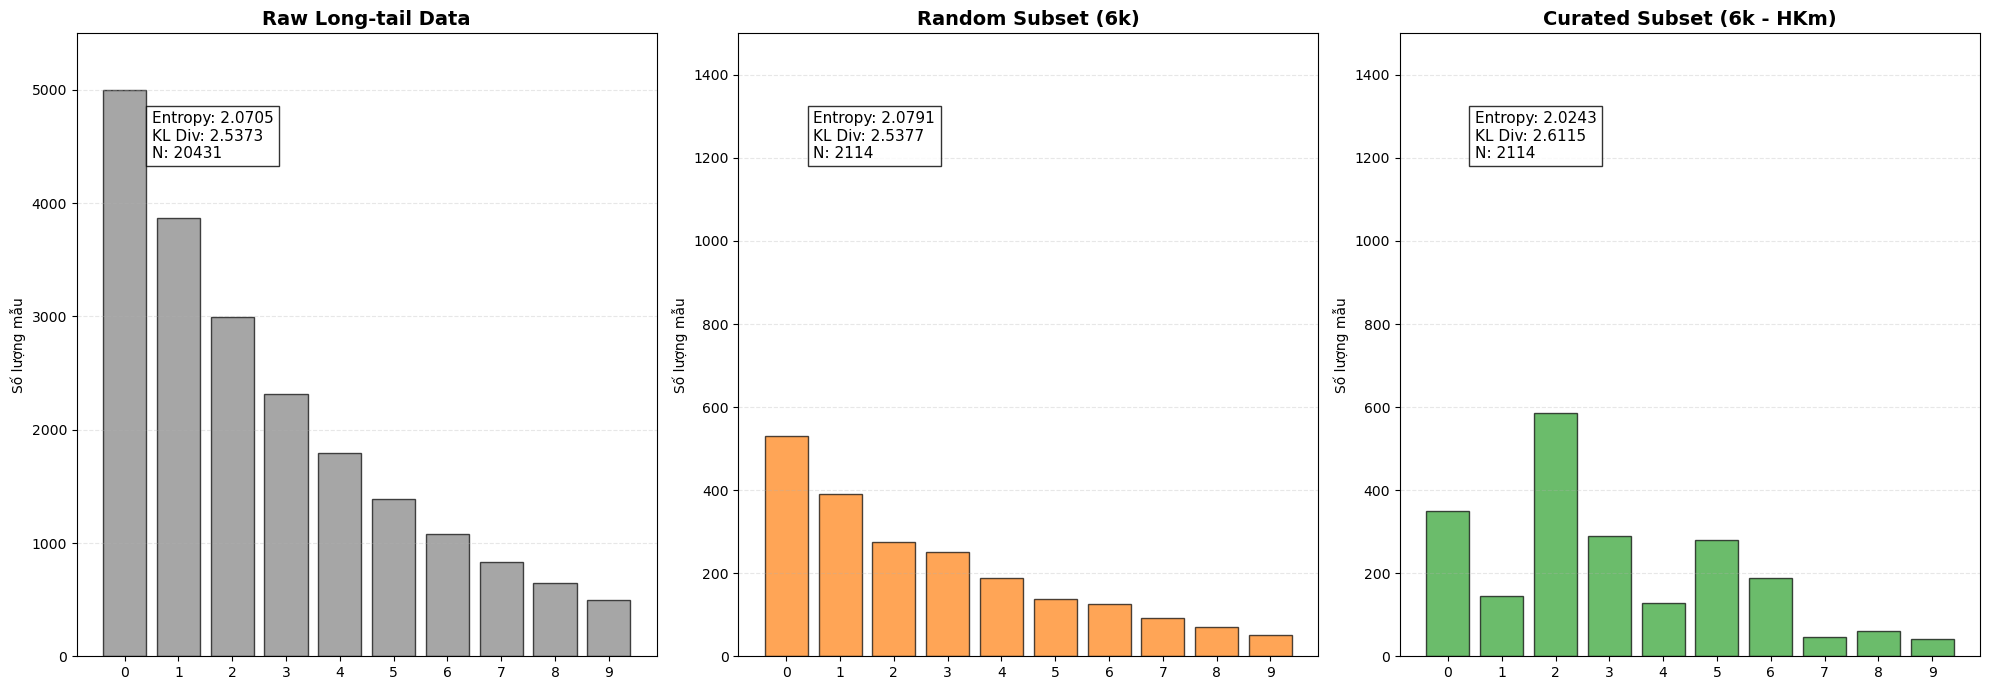

Cải thiện Entropy (Label Balance): -2.63%
Cải thiện KL Divergence (Feature Flatness): -2.91%


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Đảm bảo bạn đã chạy PCA fit trước đó để có hàm get_kl_for_subset
# PCA nên được fit trên toàn bộ X_feats_norm (vùng support gốc)

# Cố định Seed
np.random.seed(42)

# --- 1. Lấy mẫu Curated (HK-means - Strategy 'r' cho Diversity) ---
idx_curated = []
N_PER_CLUSTER = 6 # Lấy 6 ảnh/cụm * 1000 cụm = 6000 ảnh

for i in range(1000): # Chạy theo 1000 cụm mới
    cluster_idx = np.where(cluster_labels == i)[0]
    if len(cluster_idx) == 0: continue
    
    # CHIẾN THUẬT "r": Lấy ngẫu nhiên bên trong cụm thay vì lấy sát tâm
    # Điều này giúp KL Divergence không bị "vón cục" và tăng độ bao phủ Semantics
    n_draw = min(len(cluster_idx), N_PER_CLUSTER)
    pick = np.random.choice(cluster_idx, n_draw, replace=False)
    idx_curated.extend(pick)

idx_curated = np.array(idx_curated)
X_curated_feats = X_feats_norm[idx_curated]
Y_curated_subset = Y_longtail[idx_curated]

# --- 2. Lấy mẫu Ngẫu nhiên (Random) - KHỚP CHÍNH XÁC KÍCH THƯỚC ---
N_SAMPLES_TOTAL = len(idx_curated)
idx_random = np.random.choice(len(Y_longtail), N_SAMPLES_TOTAL, replace=False)
X_random_feats = X_feats_norm[idx_random]
Y_random_subset = Y_longtail[idx_random]

# --- 3. Tính toán các chỉ số ---
print(f"Đang tính toán các chỉ số cho {N_SAMPLES_TOTAL} mẫu...")

# A. Entropy (Độ cân bằng nhãn)
ent_raw = entropy(np.unique(Y_longtail, return_counts=True)[1] / len(Y_longtail))
ent_rand = entropy(np.unique(Y_random_subset, return_counts=True)[1] / len(Y_random_subset))
ent_ours = entropy(np.unique(Y_curated_subset, return_counts=True)[1] / len(Y_curated_subset))

# B. KL Divergence (Độ phẳng trong không gian đặc trưng)
# Dùng hàm get_kl_for_subset bạn đã định nghĩa ở bước trước
kl_raw = get_kl_for_subset(X_feats_norm)
kl_rand = get_kl_for_subset(X_random_feats)
kl_ours = get_kl_for_subset(X_curated_feats)

# --- 4. VẼ BIỂU ĐỒ SO SÁNH ---
def plot_high_scale_comparison(y, title, color, ent, kl, y_limit):
    cls, cnt = np.unique(y, return_counts=True)
    full_cnt = np.zeros(10); full_cnt[cls] = cnt
    plt.bar(range(10), full_cnt, color=color, alpha=0.7, edgecolor='black')
    
    # Ghi chỉ số
    stats_text = f"Entropy: {ent:.4f}\nKL Div: {kl:.4f}\nN: {len(y)}"
    plt.text(0.5, y_limit*0.8, stats_text, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylim(0, y_limit)
    plt.xticks(range(10))
    plt.ylabel("Số lượng mẫu")
    plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.figure(figsize=(20, 7))

# Subplot 1: Bể dữ liệu thô (20k ảnh)
plt.subplot(1, 3, 1)
plot_high_scale_comparison(Y_longtail, "Raw Long-tail Data", "gray", ent_raw, kl_raw, 5500)

# Subplot 2: Random Subset (6k ảnh)
plt.subplot(1, 3, 2)
plot_high_scale_comparison(Y_random_subset, "Random Subset (6k)", "tab:orange", ent_rand, kl_rand, 1500)

# Subplot 3: Curated Subset (6k ảnh - HK-means)
plt.subplot(1, 3, 3)
plot_high_scale_comparison(Y_curated_subset, "Curated Subset (6k - HKm)", "tab:green", ent_ours, kl_ours, 1500)

plt.tight_layout()
plt.show()

improvement_kl = (kl_rand - kl_ours) / kl_rand * 100
improvement_ent = (ent_ours - ent_rand) / ent_rand * 100
print(f"Cải thiện Entropy (Label Balance): {improvement_ent:.2f}%")
print(f"Cải thiện KL Divergence (Feature Flatness): {improvement_kl:.2f}%")

In [6]:
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image

# Định nghĩa lại Class Dataset để DataLoader có thể đọc được mảng ảnh
class CifarDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        # Chuyển từ numpy sang PIL Image để transform (Resize, v.v.)
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img

def extract_features_fast(X_images, batch_size=64):
    """
    Hàm trích xuất đặc trưng bằng DINOv2 theo từng Batch để tối ưu tốc độ.
    """
    dataset = CifarDataset(X_images, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    feats = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Đang trích xuất đặc trưng"):
            # 'model' và 'device' đã được định nghĩa ở các Cell setup phía trên
            batch = batch.to(device)
            feat = model(batch)
            feats.append(feat.cpu().numpy())
            
    return np.vstack(feats)

In [7]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import load_cifar10_test # Dùng tên mới cho rõ ràng

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

if 'model' not in locals():
    print("Đang tải mô hình DINOv2...")
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
    model.eval()
    print("Tải mô hình thành công!")
# 1. Load tập Test chuẩn (10.000 ảnh)
X_test_img, Y_test = load_cifar10_test('../data/cifar-10-batches-py')

# 2. Trích xuất đặc trưng cho tập Test (Dùng hàm fast có thanh process)
# Bước này mất khoảng 5-8 phút tùy máy
X_test_feats = extract_features_fast(X_test_img, batch_size=128)
X_test_feats = normalize(X_test_feats) 

print(f"Đã chuẩn bị xong đặc trưng tập Test: {X_test_feats.shape}")

Đang tải mô hình DINOv2...


Using cache found in C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\QUANG THINH/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Tải mô hình thành công!


Đang trích xuất đặc trưng: 100%|██████████| 79/79 [10:00<00:00,  7.60s/it]


Đã chuẩn bị xong đặc trưng tập Test: (10000, 384)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# Đảm bảo các biến sau đã tồn tại: 
# X_feats_norm (Train features), Y_longtail (Train labels)
# X_test_feats (Test features), Y_test (Test labels)
# idx_curated (Chỉ số tập đã lọc)

# --- 1. Huấn luyện trên TOÀN BỘ bể dữ liệu Long-tail (N ~ 20.000) ---
print(f"Đang huấn luyện trên FULL Long-tail (N={len(X_feats_norm)})...")
clf_full = LogisticRegression(max_iter=1000).fit(X_feats_norm, Y_longtail)
Y_pred_full = clf_full.predict(X_test_feats)

# --- 2. Huấn luyện trên tập Random (N = 1143 hoặc tùy cấu hình của bạn) ---
N_samples = len(idx_curated)
np.random.seed(42)
rand_idx = np.random.choice(len(X_feats_norm), N_samples, replace=False)

print(f"Đang huấn luyện trên Random Subset (N={N_samples})...")
clf_rand = LogisticRegression(max_iter=1000).fit(X_feats_norm[rand_idx], Y_longtail[rand_idx])
Y_pred_rand = clf_rand.predict(X_test_feats)

# --- 3. Huấn luyện trên tập Curated (N = 1143) ---
print(f"Đang huấn luyện trên Curated Subset (N={N_samples})...")
clf_curated = LogisticRegression(max_iter=1000).fit(X_feats_norm[idx_curated], Y_longtail[idx_curated])
Y_pred_curated = clf_curated.predict(X_test_feats)

Đang huấn luyện trên FULL Long-tail (N=20431)...
Đang huấn luyện trên Random Subset (N=2114)...
Đang huấn luyện trên Curated Subset (N=2114)...


In [11]:
from src.metrics import calculate_acc, calculate_nmi # Đảm bảo đã có trong file metrics.py
from sklearn.metrics import adjusted_rand_score

# 1. Tính toán 3 chỉ số theo yêu cầu của giảng viên
# cluster_labels là nhãn thu được từ HK-means
acc_cluster = calculate_acc(Y_longtail, cluster_labels)
nmi_cluster = calculate_nmi(Y_longtail, cluster_labels)
ari_cluster = adjusted_rand_score(Y_longtail, cluster_labels)

# 2. Tổng hợp bảng đánh giá Phân cụm (Clustering Quality)
clustering_metrics = pd.DataFrame({
    "Độ đo": ["Accuracy (Hungarian)", "NMI", "ARI"],
    "Kết quả": [acc_cluster, nmi_cluster, ari_cluster],
})

print("--- BẢNG 1: ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM (YÊU CẦU 3.2.4) ---")
print(clustering_metrics.round(4))

--- BẢNG 1: ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM (YÊU CẦU 3.2.4) ---
                  Độ đo  Kết quả
0  Accuracy (Hungarian)   0.1074
1                   NMI   0.5034
2                   ARI   0.0718


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# --- 1. Huấn luyện trên FULL Long-tail (N=20431) ---
clf_full = LogisticRegression(max_iter=1000).fit(X_feats_norm, Y_longtail)
Y_pred_full = clf_full.predict(X_test_feats)

# --- 2. Huấn luyện trên tập Random Subset ---
N_samples = len(idx_curated)
np.random.seed(42)
rand_idx = np.random.choice(len(X_feats_norm), N_samples, replace=False)
clf_rand = LogisticRegression(max_iter=1000).fit(X_feats_norm[rand_idx], Y_longtail[rand_idx])
Y_pred_rand = clf_rand.predict(X_test_feats)

# --- 3. Huấn luyện trên tập Curated Subset (Ours) ---
clf_ours = LogisticRegression(max_iter=1000).fit(X_feats_norm[idx_curated], Y_longtail[idx_curated])
Y_pred_ours = clf_ours.predict(X_test_feats)

# --- 4. TỔNG HỢP KẾT QUẢ ---
results = {
    "Dataset": ["Full Long-tail (Thô)", "Random Subset", "Curated Subset (Ours)"],
    "Kích thước (N)": [len(Y_longtail), N_samples, N_samples],
    "Accuracy": [
        accuracy_score(Y_test, Y_pred_full),
        accuracy_score(Y_test, Y_pred_rand),
        accuracy_score(Y_test, Y_pred_ours)
    ],
    "Macro F1-Score": [
        f1_score(Y_test, Y_pred_full, average='macro'),
        f1_score(Y_test, Y_pred_rand, average='macro'),
        f1_score(Y_test, Y_pred_ours, average='macro')
    ]
}

df_res = pd.DataFrame(results)
print("\n--- BẢNG 2: SO SÁNH HIỆU NĂNG HUẤN LUYỆN ---")
print(df_res.round(4))


--- BẢNG 2: SO SÁNH HIỆU NĂNG HUẤN LUYỆN ---
                 Dataset  Kích thước (N)  Accuracy  Macro F1-Score
0   Full Long-tail (Thô)           20431    0.9430          0.9431
1          Random Subset            2114    0.9042          0.9039
2  Curated Subset (Ours)            2114    0.9011          0.9003
